# Encoder baseline: fully fine-tuned DeBERTa-v3-large
### CB1 (six-class) | all 435M parameters trained

Fine-tunes `microsoft/deberta-v3-large` end to end, with no adapters and no quantization, to
establish what a much smaller encoder achieves when trained properly rather than prompted.

**Reported in:** Sec. 4.8 of the paper, Table 7.

**Protocol.** The same split, seed, preprocessing, class-weighted loss and metrics as every other
notebook here. The encoder is given three epochs with the best epoch selected on validation, a
more generous budget than the single epoch used for the adapted 9B models.

**Result.** Test Macro F1 0.9001, MCC 0.8932, 435,067,910 trainable parameters, single seed 42.

In [1]:
# ── Environment and protocol notes ────────────────────────────────────────────
# Three pins changed. Reasons:
#   datasets<4.0.0   : datasets 4.0 imports VideoReader from torchvision.io, which
#                      no longer exists in torchvision 0.26. Crashes at training time.
#   transformers cap : 4.52+ changes the Trainer eval signature this notebook relies on.
#   no torchvision / numpy / pandas pins: the old ones no longer resolve on Python 3.13
#                      and pip aborts the WHOLE command when one pin fails.
# RESTART THE RUNTIME after this cell, then run from the next cell onwards.
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q -U \
    "transformers>=4.47.0,<4.52.0" \
    "accelerate>=0.33.0" \
    "bitsandbytes>=0.43.0" \
    "peft>=0.11.1" \
    "datasets>=3.0.0,<4.0.0" \
    sentencepiece \
    protobuf \
    scikit-learn \
    matplotlib \
    seaborn

import importlib.metadata as md
for p in ['torch','transformers','peft','bitsandbytes','accelerate','datasets','numpy','pandas']:
    try:    print(f'  {p:16s} {md.version(p)}')
    except Exception: print(f'  {p:16s} NOT INSTALLED')
print()
print('>> NOW: Runtime -> Restart session. Then run from the NEXT cell. Do NOT re-run this one.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 126.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 148.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 123.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.
gradio 6.2

---

### Step 2. Imports and Google Drive

Unchanged from the other notebooks.


In [1]:
# guard against the datasets/torchvision VideoReader clash ────────
# Belt and braces. The pin above should be enough, but if Colab silently upgrades
# datasets this stops the import from reaching torchvision.io at all.
try:
    import datasets, datasets.config
    datasets.config.TORCHVISION_AVAILABLE = False
except Exception as _e:
    print('torchvision guard skipped:', _e)
# ─────────────────────────────────────────────────────────────────────────────
import os
import random
import collections
import re
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from peft.tuners.lora import LoraLayer
from google.colab import drive, userdata

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

# ── HuggingFace token (required for gated Gemma-2) ───────────────────────────
def load_hf_token() -> str:
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add it via Colab Secrets (key icon in sidebar).")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()

# ── Mount Google Drive ────────────────────────────────────────────────────────
drive.mount('/content/drive')
print("✓ Google Drive mounted.")

# ── GPU check ─────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---

### Step 3. Configuration

Loaded unchanged so the split is bit-identical to every other run. Step 4 then overrides only the model and the optimisation settings.


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

MODEL_NAME   = "google/gemma-2-9b-it"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 16, 32]

NUM_EPOCHS          = 1
LEARNING_RATE       = 5e-5   # conservative for 9B — 1e-4 caused high CV in Mistral-7B
TRAIN_BATCH_SIZE    = 4      # halved vs Mistral — 9B is ~1.3× larger
EVAL_BATCH_SIZE     = 8
WEIGHT_DECAY        = 0.01
EVAL_STEPS          = 200
LOGGING_STEPS       = 50
OUTPUT_DIR          = "/content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying':   0,
    'gender':              1,
    'religion':            2,
    'ethnicity':           3,
    'age':                 4,
    'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Model      : {MODEL_NAME}")
print(f"  LoRA rank  : {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  Batch size : {TRAIN_BATCH_SIZE} train / {EVAL_BATCH_SIZE} eval  (reduced for 9B)")
print(f"  LR         : {LEARNING_RATE}  (conservative for 9B scale)")
print(f"  Split      : {int(TRAIN_RATIO*100)}% train+val / {int(TEST_RATIO*100)}% test  (protocol: 75/25)")
print(f"  Labels ({NUM_LABELS}) : {TARGET_NAMES}")

✓ Configuration loaded.
  Model      : google/gemma-2-9b-it
  LoRA rank  : 16  |  alpha: 16  |  scaling: 1.0
  Epochs     : 1
  Batch size : 4 train / 8 eval  (reduced for 9B)
  LR         : 5e-05  (conservative for 9B scale)
  Split      : 75% train+val / 25% test  (protocol: 75/25)
  Labels (6) : ['not_cyberbullying', 'gender', 'religion', 'ethnicity', 'age', 'other_cyberbullying']


---

### Step 4. Encoder-specific settings

Overrides the model and optimiser only. The split above is untouched.


In [3]:
# ═════════════════════════════════════════════════════════════════════════════
#  STEP 4. Encoder-specific settings
#
#  Everything above this cell is shared with the LoRA notebooks so the split is
#  identical. Only the model and the optimiser settings change here. The LoRA
#  learning rate of 5e-5 would be far too high for full fine-tuning of a large
#  encoder, and DeBERTa-v3-large is known to diverge at that rate.
# ═════════════════════════════════════════════════════════════════════════════
ENCODER_NAME  = "microsoft/deberta-v3-large"
ENC_EPOCHS    = 3          # more generous than the 9B runs, on purpose
ENC_LR        = 1e-5       # standard for deberta-v3-large; 5e-5 diverges
ENC_WARMUP    = 0.10
TRAIN_BS      = 16
EVAL_BS       = 32
ENC_OUTPUT_DIR = "/content/drive/MyDrive/Results/CB1_Encoder_DeBERTa"

os.makedirs(ENC_OUTPUT_DIR, exist_ok=True)
print(f'  Encoder    : {ENCODER_NAME}')
print(f'  Epochs     : {ENC_EPOCHS}  (best epoch chosen on VALIDATION Macro F1)')
print(f'  LR         : {ENC_LR}  |  warmup {ENC_WARMUP:.0%}  |  weight decay {WEIGHT_DECAY}')
print(f'  Batch      : {TRAIN_BS} train / {EVAL_BS} eval  |  max length {MAX_LENGTH}')
print(f'  Seed       : {RANDOM_STATE}  (split, init, shuffling, dropout)')
print(f'  Output     : {ENC_OUTPUT_DIR}')


  Encoder    : microsoft/deberta-v3-large
  Epochs     : 3  (best epoch chosen on VALIDATION Macro F1)
  LR         : 1e-05  |  warmup 10%  |  weight decay 0.01
  Batch      : 16 train / 32 eval  |  max length 256
  Seed       : 42  (split, init, shuffling, dropout)
  Output     : /content/drive/MyDrive/Results/CB1_Encoder_DeBERTa


---

### Step 5. Text preprocessing

Identical to every other run in the paper.


In [4]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags:
        text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis:
        text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3:
        return ""
    return text

test_tweet = "RT @user123: Check this out http://example.com !!! @someone is so dumb"
print("Before:", test_tweet)
print("After: ", preprocess_text_for_llm(test_tweet))
print("\n✓ Preprocessing function defined.")

Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---

### Step 6. Load and clean CB1

The six-class cyberbullying corpus.


In [5]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")

df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})

corrupt_mask = df['text'].astype(str).str.strip().isin(
    ['#NAME?', '#REF!', '#VALUE!', '#N/A', 'nan', ''])
n_corrupt = corrupt_mask.sum()
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[2] Removed {n_corrupt} corrupt rows → {len(df):,} remaining")

df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[3] After preprocessing: {len(df):,} remaining")

text_label_counts = df.groupby('text')['label'].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
n_conflicting     = df['text'].isin(conflicting_texts).sum()
df = df[~df['text'].isin(conflicting_texts)].reset_index(drop=True)
print(f"[4] Removed {n_conflicting:,} annotation-conflict rows → {len(df):,} remaining")

before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[5] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")

before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} short texts → {len(df):,} remaining")

unknown_labels = set(df['label'].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown_labels) == 0, f"Unknown labels: {unknown_labels}"

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
imbalance = counts.max() / counts.min()
print(f"\n  Imbalance ratio : {imbalance:.2f}×  → no downsampling needed")
print("  Primary metric  : Macro F1  |  Secondary: MCC")

════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[2] Removed 0 corrupt rows → 47,692 remaining
[3] After preprocessing: 46,942 remaining
[4] Removed 3,250 annotation-conflict rows → 43,692 remaining
[5] Removed 358 exact duplicates → 43,334 remaining
[6] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio : 1.37×  → no downsampling needed
  Primary metric  : Macro F1  |  Secondary: MCC


---

### Step 7. Stratified 75/25 split with near-duplicate removal

**Check this prints `Train: 29,703 | Val: 3,301 | Test: 10,330`.** If it does not, the encoder is not being scored on the same test set as the LoRA runs and the row is not usable.


In [6]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end         = min(start + 500, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    max_sims    = batch_sims.max(axis=1)
    leaked_mask = max_sims >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df      = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train+val → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

overlap = set(train_val_df['text'].tolist()).intersection(set(test_df['text'].tolist()))
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed — zero train/test overlap.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE,
    stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\n[3] Validation carved → Train: {len(train_df):,} | Val: {len(val_df):,}")

print("\n" + "═" * 60)
print("FINAL SPLIT STATISTICS")
print("═" * 60)
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct = len(split_df) / len(df) * 100
    print(f"\n{name} ({len(split_df):,} samples, {pct:.1f}% of total):")
    for label, count in split_df['label'].value_counts().sort_index().items():
        print(f"  {label:<25} {count:>5}  ({count/len(split_df)*100:.1f}%)")
print(f"\n  ✓ Protocol check: test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")

════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved to train+val → Train+Val: 33,004 | Test: 10,330

    ✓ Data leakage assertion passed — zero train/test overlap.

[3] Validation carved → Train: 29,703 | Val: 3,301

════════════════════════════════════════════════════════════
FINAL SPLIT STATISTICS
════════════════════════════════════════════════════════════

Train (29,703 samples, 68.5% of total):
  age                        5420  (18.2%)
  ethnicity                  5497  (18.5%)
  gender                     5149  (17.3%)
  not_cyberbullying          4235  (14.3%)
  other_cyberbullying        3995  (13.4%)
  religion                   5407  (18.2%)

Validation (3,301 samples, 7.6% of total):
  age                 

---

### Step 8. Class weights

The same weighted loss the 9B runs used, so neither side gets an advantage.


In [7]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    if df.empty:
        return None
    df_mapped = df.copy()
    if df_mapped[label_col].dtype == object:
        df_mapped[label_col] = df_mapped[label_col].map(LABEL_MAPPING)
    class_counts = df_mapped[label_col].value_counts().sort_index()
    N = class_counts.sum(); C = len(class_counts)
    weights = N / (C * class_counts.values)
    weights = weights / weights.sum()
    return weights.tolist()

train_class_weights = get_class_weights(train_df)
print("Class weights (inverse frequency, normalised):")
for label_name, w in zip(TARGET_NAMES, train_class_weights):
    print(f"  {label_name:<25}  weight = {w:.4f}")
print("\n✓ Class weights computed.")

Class weights (inverse frequency, normalised):
  not_cyberbullying          weight = 0.1917
  gender                     weight = 0.1576
  religion                   weight = 0.1501
  ethnicity                  weight = 0.1477
  age                        weight = 0.1498
  other_cyberbullying        weight = 0.2032

✓ Class weights computed.


---

### Step 9. Evaluation metrics

Macro F1 primary, MCC secondary, plus the per-class report.


In [8]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true: List[int], y_pred: List[int],
                     dataset_name: str) -> Dict[str, float]:
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_LABELS)),
                                 target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}', fontsize=12)
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised — Recall)\n{dataset_name}', fontsize=12)
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1,
            'weighted_f1': weighted_f1, 'balanced_accuracy': bal_accuracy, 'mcc': mcc}


def make_predictions(model, df_test, tokenizer, batch_size=16):
    model.eval()
    sentences  = df_test['text'].tolist()
    all_logits = []
    dev        = next(model.parameters()).device
    with torch.no_grad():
        for start in range(0, len(sentences), batch_size):
            batch   = sentences[start:start + batch_size]
            inputs  = tokenizer(batch, return_tensors="pt",
                                padding=True, truncation=True, max_length=MAX_LENGTH)
            inputs  = {k: v.to(dev) for k, v in inputs.items()}
            outputs = model(**inputs)
            all_logits.append(outputs.logits.cpu())
    all_logits         = torch.cat(all_logits, dim=0)
    df_test            = df_test.copy()
    df_test['predictions'] = all_logits.argmax(dim=1).numpy()
    return df_test

print("✓ Metric functions defined.")

✓ Metric functions defined.


---

### Step 9b. Stability callback and weighted-loss trainer

Reused unchanged.


In [9]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.val_metrics  = collections.defaultdict(list)
        self.val_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs:
            self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            self.val_metrics[key.replace('eval_', '')].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr)/np.mean(arr)) if np.mean(arr)>0 else 0.0
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max()-arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])
        loss_cv = report.get('loss_cv_overall', 0.0)
        f1_std  = report.get('val_f1_std', 0.0)
        report['stability_score'] = round((loss_cv * 0.5) + (f1_std * 0.5), 6)
        return report

    def plot_stability_curves(self, stage_label: str = 'Stage 2', save_path: str = None):
        """2-panel stability figure (single-epoch protocol)."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        if self.train_losses:
            steps  = [s for (s, _) in self.train_losses]
            losses = [l for (_, l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7,
                     alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy', linewidth=2.2,
                         label=f'Rolling mean (w={window})')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)
            ax1.set_xlabel('Global Step'); ax1.set_ylabel('Cross-Entropy Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No training loss data.', ha='center', va='center',
                     transform=ax1.transAxes, fontsize=10, color='grey')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)

        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen',
                         linewidth=2, markersize=5, label='Macro F1')
                f1_mean = float(np.mean(f1_vals)); f1_std = float(np.std(f1_vals))
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':', linewidth=1.2, alpha=0.6)
                ax2.fill_between(self.val_steps,
                                  [f1_mean-f1_std]*len(self.val_steps),
                                  [f1_mean+f1_std]*len(self.val_steps),
                                  color='forestgreen', alpha=0.10,
                                  label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen', fontsize=10)
                ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2_r is not None and 'mcc' in self.val_metrics:
                ax2_r.plot(self.val_steps, self.val_metrics['mcc'], 's--',
                           color='darkorange', linewidth=2, markersize=5, label='MCC')
                ax2_r.set_ylabel('MCC', color='darkorange', fontsize=10)
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
                lines1, lbl1 = ax2.get_legend_handles_labels()
                lines2, lbl2 = ax2_r.get_legend_handles_labels()
                ax2.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='lower right')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)
            ax2.set_xlabel('Global Step'); ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No validation data.', ha='center', va='center',
                     transform=ax2.transAxes, fontsize=10, color='grey')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)

        plt.suptitle(f'Training Stability Analysis — {stage_label}',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'  ✓ Stability plot saved → {save_path}')
        plt.show()


class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
            if class_weights is not None else None)

    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels  = inputs.pop('labels').long()
        outputs = model(**inputs)
        loss    = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss


def plot_cross_stage_stability(stage_reports: Dict[str, Dict], save_path: str = None):
    labels  = list(stage_reports.keys())
    n       = len(labels)
    colours = ['#2E75B6', '#2E86AB', '#1B998B', '#F4A261'][:n]
    metrics_map = {
        'Loss Std Dev\n(Overall)':              'loss_std_overall',
        'Loss CV\n(Coeff. of Variation)':       'loss_cv_overall',
        'Val F1 Std Dev\n(Across Checkpoints)': 'val_f1_std',
        'Composite\nStability Score':           'stability_score',
    }
    fig, axes = plt.subplots(1, len(metrics_map), figsize=(5.5*len(metrics_map), 6))
    for ax, (metric_label, metric_key) in zip(axes, metrics_map.items()):
        values = [stage_reports[lbl].get(metric_key, 0.0) or 0.0 for lbl in labels]
        bars   = ax.bar(range(n), values, color=colours, alpha=0.85,
                        edgecolor='white', linewidth=1.5, width=0.6)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(values+[1e-9])*0.03,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(metric_label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value  (lower = more stable)', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        if metric_key == 'stability_score':
            ax.axhspan(0, 0.05, alpha=0.08, color='green', label='Very stable')
            ax.axhspan(0.05, 0.15, alpha=0.08, color='orange', label='Acceptable')
            ax.axhspan(0.15, max(values+[0.2])*1.2, alpha=0.08, color='red', label='Unstable')
            ax.legend(fontsize=8, loc='upper left')
    plt.suptitle(
        'Cross-Stage Training Stability Comparison\n'
        'CB1 — 6-Class Cyberbullying | google/gemma-2-9b-it',
        fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  ✓ Cross-stage stability plot saved → {save_path}')
    plt.show()

print('✓ StabilityCallback (2-dimension, single-epoch protocol) defined.')
print('  [Panels 3 & 4 removed — uninformative with 1 epoch]')
print('✓ CustomTrainer defined.')
print('✓ plot_cross_stage_stability() defined.')

✓ StabilityCallback (2-dimension, single-epoch protocol) defined.
  [Panels 3 & 4 removed — uninformative with 1 epoch]
✓ CustomTrainer defined.
✓ plot_cross_stage_stability() defined.


---

### Step 10. Train the encoder

**The only cell that trains.** About 1 hour on an A100.

Before training starts it must print `Trainable: 435,...` with `(100.0%)`, and the assertion `n_train == n_total` must pass. If any parameter is frozen this is not a full fine-tune and the row cannot answer R2.

On out-of-memory, set `TRAIN_BS = 8` in Step 4 and run this cell again.


✓ All random seeds fixed to 42.
[1] Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


...

   Trainable: 435,067,910 / 435,067,910  (100.0%)
[4] Training — 3 epochs, best epoch selected on VALIDATION Macro F1...


model.safetensors:   0%|          | 0.00/874M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Mcc
1,0.387000,0.294398,0.913663,0.903920,0.896188
2,0.240500,0.308482,0.916086,0.906665,0.899132
3,0.151400,0.353357,0.921539,0.912304,0.905577


   training wall clock: 0.41 h



[5] VALIDATION Macro F1 of the selected checkpoint: 0.9123   <-- SELECTION USES THIS, NOT THE TEST SCORE
[6] Running inference on the held-out test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — DeBERTaV3Large_fullFT
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9113
  Macro F1          : 0.9001  ← PRIMARY METRIC
  Weighted F1       : 0.9115
  Balanced Accuracy : 0.9002
  MCC               : 0.8932  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7561    0.7598    0.7580      1424
             gender     0.9105    0.9100    0.9102      1788
           religion     0.9640    0.9655    0.9648      1971
          ethnicity     0.9857    0.9868    0.9862      1812
                age     0.9824    0.9733    0.9778      1950
other_cyberbullying     0.8017    0.8058    0.8037      1385

           accuracy  

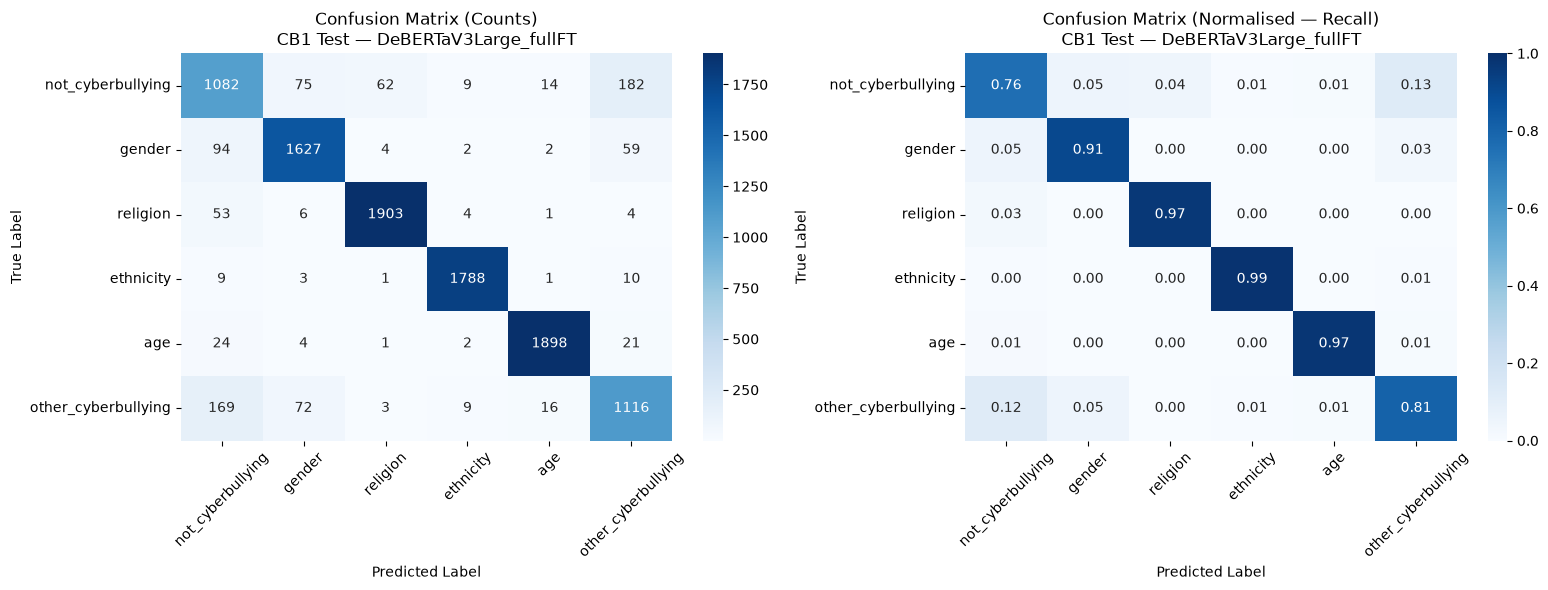


Saved -> /content/drive/MyDrive/Results/CB1_Encoder_DeBERTa/DeBERTaV3Large_fullFT/results_DeBERTaV3Large_fullFT.csv

ENCODER BASELINE vs THE ADAPTED 9B MODEL  --  CB1, test Macro F1
Method                         |     Trainable |  Macro F1 | note
----------------------------------------------------------------------------------------------
DeBERTa-v3-large zero-shot     |           n/a |    0.3129 | from the manuscript, Sec. 4.1
DeBERTa-v3-large full FT       |   435,067,910 |    0.9001 | this run, 3 epochs, seed 42
Additive LoRA  r=32            |    35,804,160 |    0.9007 | mean of 3 seeds
Multiplicative r=32            |    39,911,424 |    0.8943 | mean of 3 seeds
DoRA           r=32            |    36,298,752 |    0.9014 | single seed 42
Joint (ours)   r=8             |    18,945,024 |    0.9034 | mean of 3 seeds

Joint (0.9034) minus the fully fine-tuned encoder: +0.0033
Encoder trains 435,067,910 parameters; the joint method trains 18,945,024
  ratio: 22.96x more trainable para

In [10]:
# ═════════════════════════════════════════════════════════════════════════════
#  STEP 10. Fully fine-tune DeBERTa-v3-large on CB1
#
#  All 435M parameters are trained. No quantisation, no adapters.
#  Selection is on validation Macro F1. The test set is touched once, at the end.
#
#  RESUME-SAFE. If the session drops, re-run this cell; a finished run is
#  reloaded from Drive and skipped.
# ═════════════════════════════════════════════════════════════════════════════
import time, json, math
from transformers import AutoModelForSequenceClassification, AutoTokenizer

RUN_LABEL = 'DeBERTaV3Large_fullFT'
run_dir   = os.path.join(ENC_OUTPUT_DIR, RUN_LABEL)
os.makedirs(run_dir, exist_ok=True)
res_csv   = os.path.join(run_dir, f'results_{RUN_LABEL}.csv')

if os.path.exists(res_csv):
    enc_res = pd.read_csv(res_csv).iloc[0].to_dict()
    print('Recovered a finished run from Drive. Delete this file to force a rerun:')
    print('  ', res_csv)
else:
    set_all_seeds(RANDOM_STATE)
    t0 = time.time()

    # ── 1. Tokenizer ─────────────────────────────────────────────────────────
    print('[1] Loading tokenizer...')
    tok = AutoTokenizer.from_pretrained(ENCODER_NAME)
    print(f'   Vocab size: {tok.vocab_size:,}  |  pad "{tok.pad_token}" (id={tok.pad_token_id})')

    def tokenise(ex):
        return tok(ex['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

    # ── 2. Datasets, identical splits to the LoRA runs ───────────────────────
    print('[2] Mapping labels and preparing datasets...')
    tr, va, te = train_df.copy(), val_df.copy(), test_df.copy()
    for sp in (tr, va, te):
        sp['label'] = sp['label'].map(LABEL_MAPPING)
        assert sp['label'].notnull().all(), 'unmapped labels'
    mk = lambda d: Dataset.from_pandas(d[['text','label']].reset_index(drop=True)) \
                          .map(tokenise, batched=True, remove_columns=['text'])
    hf_train, hf_val, hf_test = mk(tr), mk(va), mk(te)
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(hf_test):,}')
    assert len(hf_test) == len(test_df), 'test set size changed'

    # ── 3. Model, full precision weights, bf16 autocast during training ──────
    print('[3] Loading model for FULL fine-tuning (no quantisation, no adapters)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        ENCODER_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL,
        label2id=LABEL_MAPPING)
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'   Trainable: {n_train:,} / {n_total:,}  ({100*n_train/n_total:.1f}%)')
    assert n_train == n_total, 'something is frozen; this must be a FULL fine-tune'

    # ── 4. Training ──────────────────────────────────────────────────────────
    print(f'[4] Training — {ENC_EPOCHS} epochs, best epoch selected on VALIDATION Macro F1...')
    ta_kw = dict(
        output_dir='/content/enc_ckpt',   # local disk, NOT Drive:
                                          # deberta-v3-large checkpoints are ~1.7 GB each
                                          # and only the final metrics need to persist
        num_train_epochs=ENC_EPOCHS,
        per_device_train_batch_size=TRAIN_BS,
        per_device_eval_batch_size=EVAL_BS,
        learning_rate=ENC_LR,
        warmup_ratio=ENC_WARMUP,
        weight_decay=WEIGHT_DECAY,
        logging_steps=LOGGING_STEPS,
        save_total_limit=2,      # best + last, so rotation cannot delete the best
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        bf16=torch.cuda.is_bf16_supported(),
        fp16=not torch.cuda.is_bf16_supported(),
        seed=RANDOM_STATE,
        data_seed=RANDOM_STATE,
        report_to='none',
        save_safetensors=True,
    )
    try:      # transformers >= 4.41
        targs = TrainingArguments(eval_strategy='epoch', save_strategy='epoch', **ta_kw)
    except TypeError:
        targs = TrainingArguments(evaluation_strategy='epoch', save_strategy='epoch', **ta_kw)

    stab = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=targs,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics,
        class_weights=train_class_weights,
        callbacks=[stab])
    trainer.train()
    train_hours = (time.time() - t0) / 3600
    print(f'   training wall clock: {train_hours:.2f} h')

    # ── 5. Validation score of the selected model ────────────────────────────
    val_metrics = trainer.evaluate(eval_dataset=hf_val)
    val_best = float(val_metrics['eval_f1'])
    print(f'\n[5] VALIDATION Macro F1 of the selected checkpoint: {val_best:.4f}'
          f'   <-- SELECTION USES THIS, NOT THE TEST SCORE')

    # ── 6. Test set, touched once ────────────────────────────────────────────
    print('[6] Running inference on the held-out test set...')
    pred   = trainer.predict(hf_test)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_true = np.array(te['label'].tolist())
    m = evaluate_dataset(y_true, y_pred, f'CB1 Test — {RUN_LABEL}')

    enc_res = {'run_label': RUN_LABEL, 'model': ENCODER_NAME,
               'trainable_params': n_train, 'total_params': n_total,
               'epochs': ENC_EPOCHS, 'lr': ENC_LR,
               'val_f1_best': val_best,
               'macro_f1': m['macro_f1'] if isinstance(m, dict) and 'macro_f1' in m
                           else float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
               'mcc': float(matthews_corrcoef(y_true, y_pred)),
               'accuracy': float(accuracy_score(y_true, y_pred)),
               'train_hours': train_hours}
    pd.DataFrame([enc_res]).to_csv(res_csv, index=False)
    print(f'\nSaved -> {res_csv}')

# ── comparison table ─────────────────────────────────────────────────────────
REF = [('DeBERTa-v3-large zero-shot', None,      0.3129, 'from the manuscript, Sec. 4.1'),
       ('DeBERTa-v3-large full FT',   enc_res['trainable_params'],
                                      float(enc_res['macro_f1']), 'this run, 3 epochs, seed 42'),
       ('Additive LoRA  r=32',        35_804_160, 0.9007, 'mean of 3 seeds'),
       ('Multiplicative r=32',        39_911_424, 0.8943, 'mean of 3 seeds'),
       ('DoRA           r=32',        36_298_752, 0.9014, 'single seed 42'),
       ('Joint (ours)   r=8',         18_945_024, 0.9034, 'mean of 3 seeds')]

print('\n' + '='*94)
print('ENCODER BASELINE vs THE ADAPTED 9B MODEL  --  CB1, test Macro F1')
print('='*94)
print(f'{"Method":30} | {"Trainable":>13} | {"Macro F1":>9} | note')
print('-'*94)
for name, prm, f1, note in REF:
    p = f'{prm:,}' if prm else 'n/a'
    print(f'{name:30} | {p:>13} | {f1:>9.4f} | {note}')

gap = 0.9034 - float(enc_res['macro_f1'])
print(f'\nJoint (0.9034) minus the fully fine-tuned encoder: {gap:+.4f}')
print(f'Encoder trains {enc_res["trainable_params"]:,} parameters; the joint method trains 18,945,024')
print(f'  ratio: {enc_res["trainable_params"]/18_945_024:.2f}x more trainable parameters in the encoder')
print('\n  Note for the manuscript: the encoder is far smaller at inference (about 435M against 9B)')
print('  but trains every one of its parameters, while the joint method trains 18.9M on top of a')
print('  frozen backbone. Report both, and say the encoder was given 3 epochs to the 9B model\'s 1.')
